<a href="https://colab.research.google.com/github/AreHand/calgary-household-energy-analysis/blob/main/calgary_energy_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1: INSTALL
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels plotly xgboost lightgbm google-cloud-bigquery db-dtypes

# CELL 2: IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Style
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = px.colors.qualitative.Set2
print("✅ All imports successful")

✅ All imports successful


In [2]:
# CELL 3: LOAD DATA
from google.colab import auth
from google.cloud import bigquery
import pandas as pd
import os

# --- CHOOSE YOUR DATA SOURCE ---
DATA_SOURCE = 'UPLOAD_CSV' # Options: 'BIGQUERY' or 'UPLOAD_CSV'

if DATA_SOURCE == 'BIGQUERY':
    auth.authenticate_user()
    PROJECT_ID = "calgary-energy-analysis"  # Double check this project ID
    client = bigquery.Client(project=PROJECT_ID)

    query = """
    SELECT * FROM `calgary_energy.household_energy_clean`
    ORDER BY Household_ID, Date
    """
    try:
        df = client.query(query).to_dataframe()
        print(f"✅ Data loaded from BigQuery: {df.shape}")
    except Exception as e:
        print(f"❌ BigQuery Error: {e}")
        print("Try switching DATA_SOURCE to 'UPLOAD_CSV' if the table is not found.")

elif DATA_SOURCE == 'UPLOAD_CSV':
    from google.colab import files
    print("Please upload your 'calgary_household_energy_synthetic.csv' file:")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    df = pd.read_csv(filename)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    print(f"✅ Data loaded from CSV: {df.shape}")

if 'df' in locals():
    display(df.head())
    print(df.dtypes)

Please upload your 'calgary_household_energy_synthetic.csv' file:


Saving calgary_household_energy_synthetic.csv to calgary_household_energy_synthetic.csv
✅ Data loaded from CSV: (102340, 11)


,Household_ID,Date,Outside_Temperature_C,Household_Size,Living_Area_m2,Has_EV_Car,Max_AC_Hours,AC_Hours_Used,Tariff_Rate_CAD_kWh,Daily_kWh,Daily_Cost_CAD
0,HH_001,2024-01-01,-11.9,5,86,1,6,0.0,0.105,18.726,1.9662
1,HH_001,2024-01-02,-9.6,5,86,1,6,0.0,0.105,28.272,2.9686
2,HH_001,2024-01-03,-10.4,5,86,1,6,0.0,0.105,30.348,3.1865
3,HH_001,2024-01-04,-1.9,5,86,1,6,0.0,0.105,27.031,2.8383
4,HH_001,2024-01-05,-1.7,5,86,1,6,0.0,0.105,23.159,2.4317


Household_ID                     object
Date                     datetime64[ns]
Outside_Temperature_C           float64
Household_Size                    int64
Living_Area_m2                    int64
Has_EV_Car                        int64
Max_AC_Hours                      int64
AC_Hours_Used                   float64
Tariff_Rate_CAD_kWh             float64
Daily_kWh                       float64
Daily_Cost_CAD                  float64
dtype: object


In [3]:
# CELL 4: PREPROCESSING
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Household_ID', 'Date']).reset_index(drop=True)

# Derived columns (kalau load dari CSV)
if 'Season' not in df.columns:
    df['Year']   = df['Date'].dt.year
    df['Month']  = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['DayName'] = df['Date'].dt.day_name()
    df['WeekNum'] = df['Date'].dt.isocalendar().week.astype(int)
    df['YearMonth'] = df['Date'].dt.to_period('M')

    season_map = {12:'Winter',1:'Winter',2:'Winter',
                  3:'Spring',4:'Spring',5:'Spring',
                  6:'Summer',7:'Summer',8:'Summer',
                  9:'Fall',10:'Fall',11:'Fall'}
    df['Season'] = df['Month'].map(season_map)
    df['kWh_per_m2'] = df['Daily_kWh'] / df['Living_Area_m2']
    df['kWh_per_person'] = df['Daily_kWh'] / df['Household_Size']
    df['EV_Label'] = df['Has_EV_Car'].map({1:'EV Owner', 0:'Non-EV'})

# Encode for ML
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['Temp_Squared'] = df['Outside_Temperature_C'] ** 2  # non-linear heating/cooling
df['Heating_Degree'] = (-df['Outside_Temperature_C']).clip(lower=0)  # HDD proxy
df['Cooling_Degree'] = (df['Outside_Temperature_C'] - 18).clip(lower=0)  # CDD proxy

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Households: {df['Household_ID'].nunique()}")
print(f"Null values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
df.describe()

Shape: (102340, 25)
Date range: 2024-01-01 00:00:00 → 2025-12-31 00:00:00
Households: 140
Null values:
Series([], dtype: int64)


,Date,Outside_Temperature_C,Household_Size,Living_Area_m2,Has_EV_Car,Max_AC_Hours,AC_Hours_Used,Tariff_Rate_CAD_kWh,Daily_kWh,Daily_Cost_CAD,Year,Month,DayOfWeek,WeekNum,kWh_per_m2,kWh_per_person,Is_Weekend,Temp_Squared,Heating_Degree,Cooling_Degree
count,102340,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000,102340.000000
mean,2024-12-30 23:59:59.999999744,3.804330,4.121429,89.207143,0.385714,4.871429,0.038849,0.107590,16.601791,1.786367,2024.499316,6.519836,2.991792,26.395349,0.217408,4.493353,0.284542,120.837398,2.864241,0.065144
min,2024-01-01 00:00:00,-28.400000,2.000000,25.000000,0.000000,0.000000,0.000000,0.080000,4.013000,0.368200,2024.000000,1.000000,0.000000,1.000000,0.045787,0.949167,0.000000,0.000000,0.000000,0.000000
25%,2024-07-01 00:00:00,-5.200000,3.000000,56.000000,0.000000,2.000000,0.000000,0.092000,10.992000,1.152100,2024.000000,4.000000,1.000000,13.000000,0.132235,2.700729,0.000000,24.010000,0.000000,0.000000
50%,2024-12-31 00:00:00,4.500000,4.000000,88.500000,0.000000,4.000000,0.000000,0.110000,15.194000,1.618000,2024.000000,7.000000,3.000000,26.000000,0.188880,3.818733,0.000000,90.250000,0.000000,0.000000
75%,2025-07-02 00:00:00,13.300000,5.000000,121.000000,1.000000,8.000000,0.000000,0.120600,21.102000,2.274000,2025.000000,10.000000,5.000000,39.000000,0.268387,5.500687,1.000000,198.810000,5.200000,0.000000
max,2025-12-31 00:00:00,24.000000,6.000000,150.000000,1.000000,10.000000,7.800000,0.120600,52.363000,6.315000,2025.000000,12.000000,6.000000,52.000000,1.227346,20.140000,1.000000,806.560000,28.400000,6.000000
std,NaN,10.313366,1.391141,37.461686,0.486766,3.118721,0.271903,0.014439,7.104054,0.810370,0.500002,3.449568,2.000677,15.066036,0.122586,2.533369,0.451198,110.539763,4.534285,0.357880


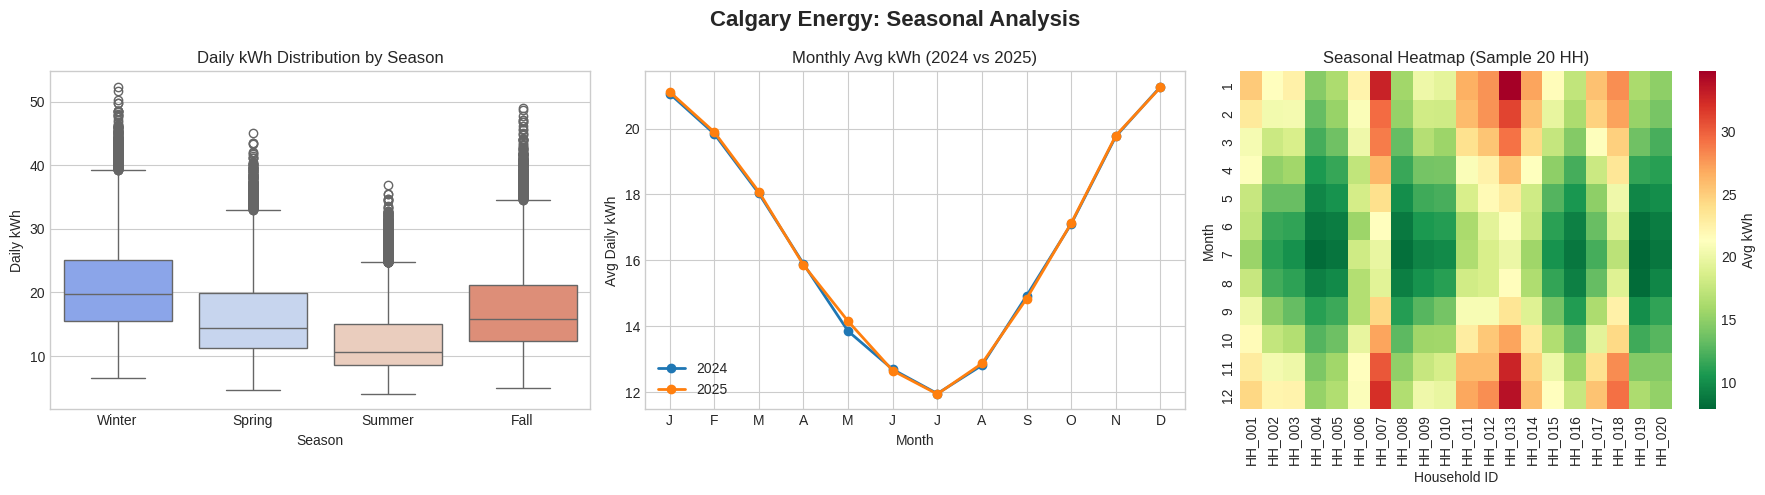

📊 Analysis 1 Complete


In [4]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 1: POLA MUSIMAN            ║
# ╚══════════════════════════════════════╝
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Calgary Energy: Seasonal Analysis', fontsize=16, fontweight='bold')

# 1A: Boxplot per season
season_order = ['Winter','Spring','Summer','Fall']
season_data = df.groupby(['Season', 'Year'])['Daily_kWh'].mean().reset_index()
sns.boxplot(data=df, x='Season', y='Daily_kWh', order=season_order,
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Daily kWh Distribution by Season')
axes[0].set_xlabel('Season'); axes[0].set_ylabel('Daily kWh')

# 1B: Monthly avg across 2 years
monthly = df.groupby(['Year','Month'])['Daily_kWh'].mean().reset_index()
for year in [2024, 2025]:
    subset = monthly[monthly['Year']==year]
    axes[1].plot(subset['Month'], subset['Daily_kWh'], marker='o',
                 label=str(year), linewidth=2)
axes[1].set_title('Monthly Avg kWh (2024 vs 2025)')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg Daily kWh')
axes[1].legend(); axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])

# 1C: Heatmap month x household
pivot = df.groupby(['Month','Household_ID'])['Daily_kWh'].mean().unstack()
pivot_sample = pivot.iloc[:, :20]  # 20 households
sns.heatmap(pivot_sample, cmap='RdYlGn_r', ax=axes[2],
            cbar_kws={'label': 'Avg kWh'})
axes[2].set_title('Seasonal Heatmap (Sample 20 HH)')
axes[2].set_xlabel('Household ID')

plt.tight_layout()
plt.savefig('analysis_01_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Analysis 1 Complete")

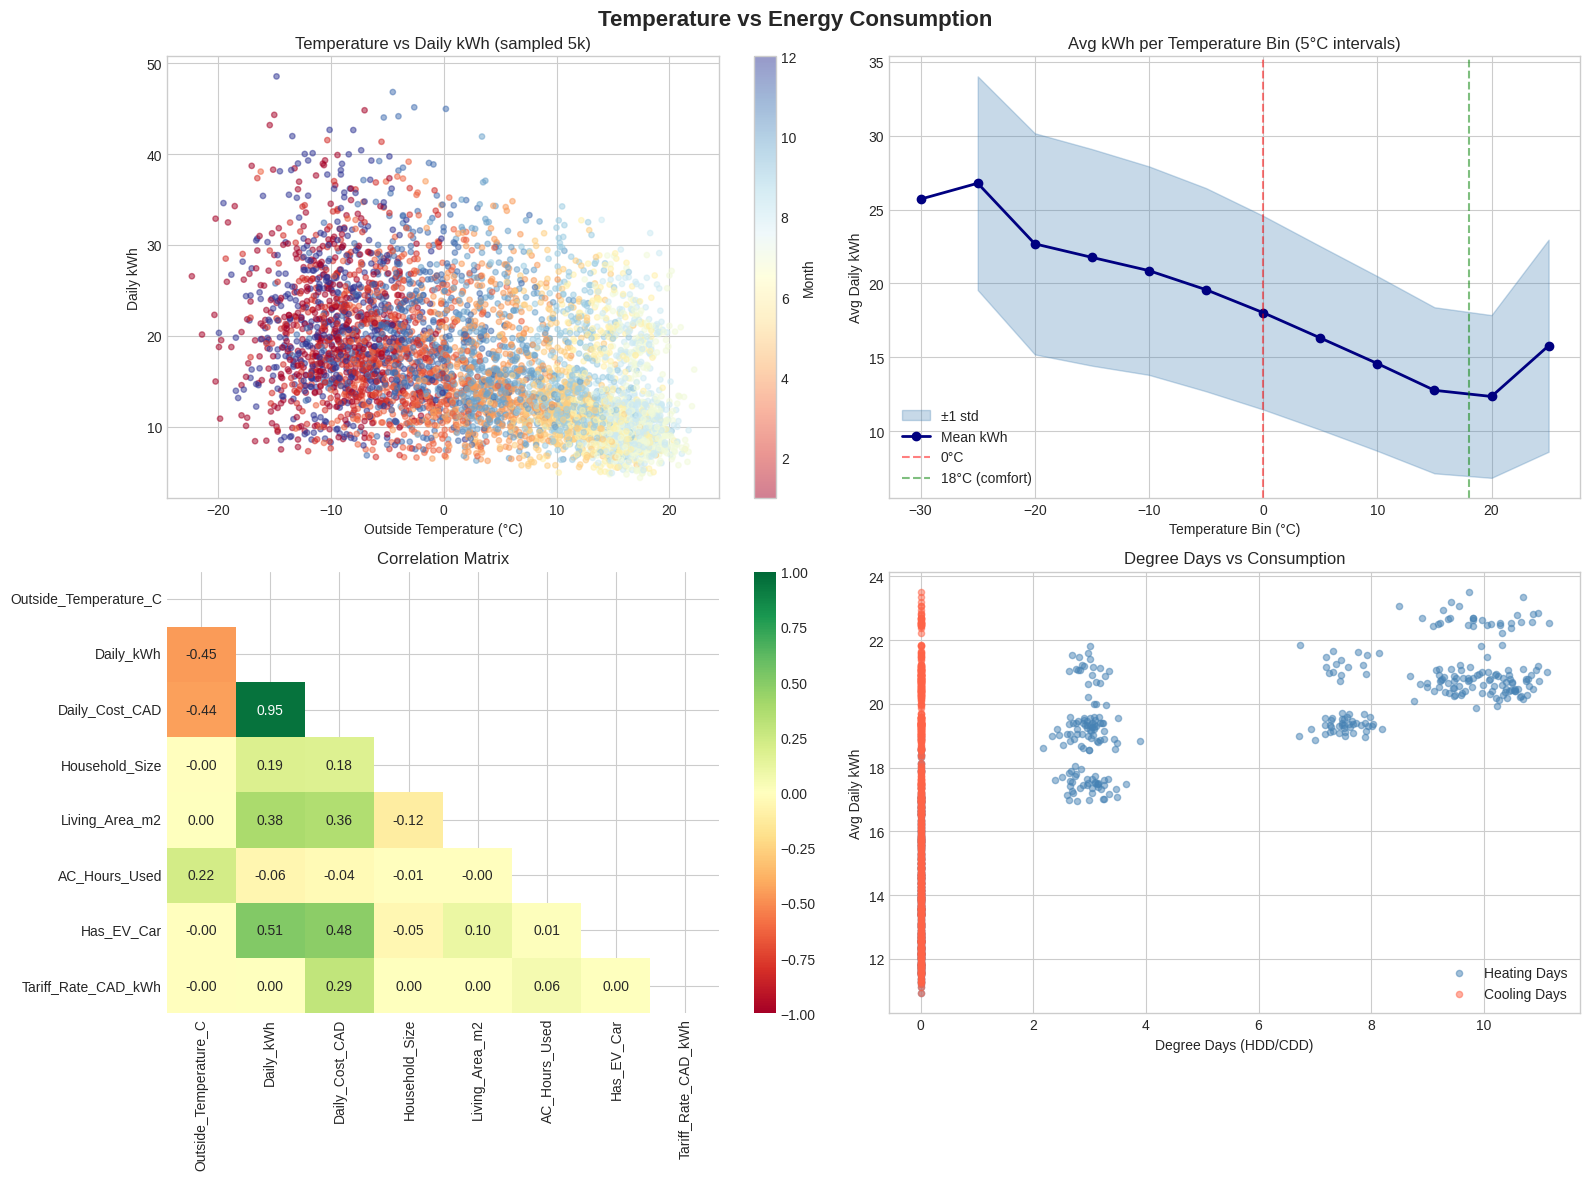

In [5]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 2: KORELASI SUHU           ║
# ╚══════════════════════════════════════╝
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Temperature vs Energy Consumption', fontsize=16, fontweight='bold')

# 2A: Scatter plot suhu vs kWh
sample = df.sample(5000, random_state=42)
scatter = axes[0,0].scatter(sample['Outside_Temperature_C'], sample['Daily_kWh'],
                             c=sample['Month'], cmap='RdYlBu', alpha=0.5, s=15)
axes[0,0].set_xlabel('Outside Temperature (°C)')
axes[0,0].set_ylabel('Daily kWh')
axes[0,0].set_title('Temperature vs Daily kWh (sampled 5k)')
plt.colorbar(scatter, ax=axes[0,0], label='Month')

# 2B: Binned average (setiap 5 derajat)
df['Temp_Bin'] = (df['Outside_Temperature_C'] / 5).round() * 5
temp_bin = df.groupby('Temp_Bin')['Daily_kWh'].agg(['mean','std','count']).reset_index()
axes[0,1].fill_between(temp_bin['Temp_Bin'],
                        temp_bin['mean'] - temp_bin['std'],
                        temp_bin['mean'] + temp_bin['std'],
                        alpha=0.3, color='steelblue', label='±1 std')
axes[0,1].plot(temp_bin['Temp_Bin'], temp_bin['mean'], 'o-',
               color='navy', linewidth=2, label='Mean kWh')
axes[0,1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='0°C')
axes[0,1].axvline(x=18, color='green', linestyle='--', alpha=0.5, label='18°C (comfort)')
axes[0,1].set_xlabel('Temperature Bin (°C)')
axes[0,1].set_ylabel('Avg Daily kWh')
axes[0,1].set_title('Avg kWh per Temperature Bin (5°C intervals)')
axes[0,1].legend()

# 2C: Correlation matrix
corr_cols = ['Outside_Temperature_C','Daily_kWh','Daily_Cost_CAD',
             'Household_Size','Living_Area_m2','AC_Hours_Used',
             'Has_EV_Car','Tariff_Rate_CAD_kWh']
corr_df = df[corr_cols].astype(float)
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=axes[1,0], vmin=-1, vmax=1, center=0)
axes[1,0].set_title('Correlation Matrix')

# 2D: Heating/Cooling Degree Days
hdd_cdd = df.groupby('Date').agg(
    Avg_Temp=('Outside_Temperature_C','mean'),
    Avg_kWh=('Daily_kWh','mean')
).reset_index()
hdd_cdd['HDD'] = (-hdd_cdd['Avg_Temp']).clip(lower=0)
hdd_cdd['CDD'] = (hdd_cdd['Avg_Temp']-18).clip(lower=0)

axes[1,1].scatter(hdd_cdd['HDD'], hdd_cdd['Avg_kWh'],
                  alpha=0.5, color='steelblue', s=20, label='Heating Days')
axes[1,1].scatter(hdd_cdd['CDD'], hdd_cdd['Avg_kWh'],
                  alpha=0.5, color='tomato', s=20, label='Cooling Days')
axes[1,1].set_xlabel('Degree Days (HDD/CDD)')
axes[1,1].set_ylabel('Avg Daily kWh')
axes[1,1].set_title('Degree Days vs Consumption')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('analysis_02_temperature.png', dpi=150, bbox_inches='tight')
plt.show()

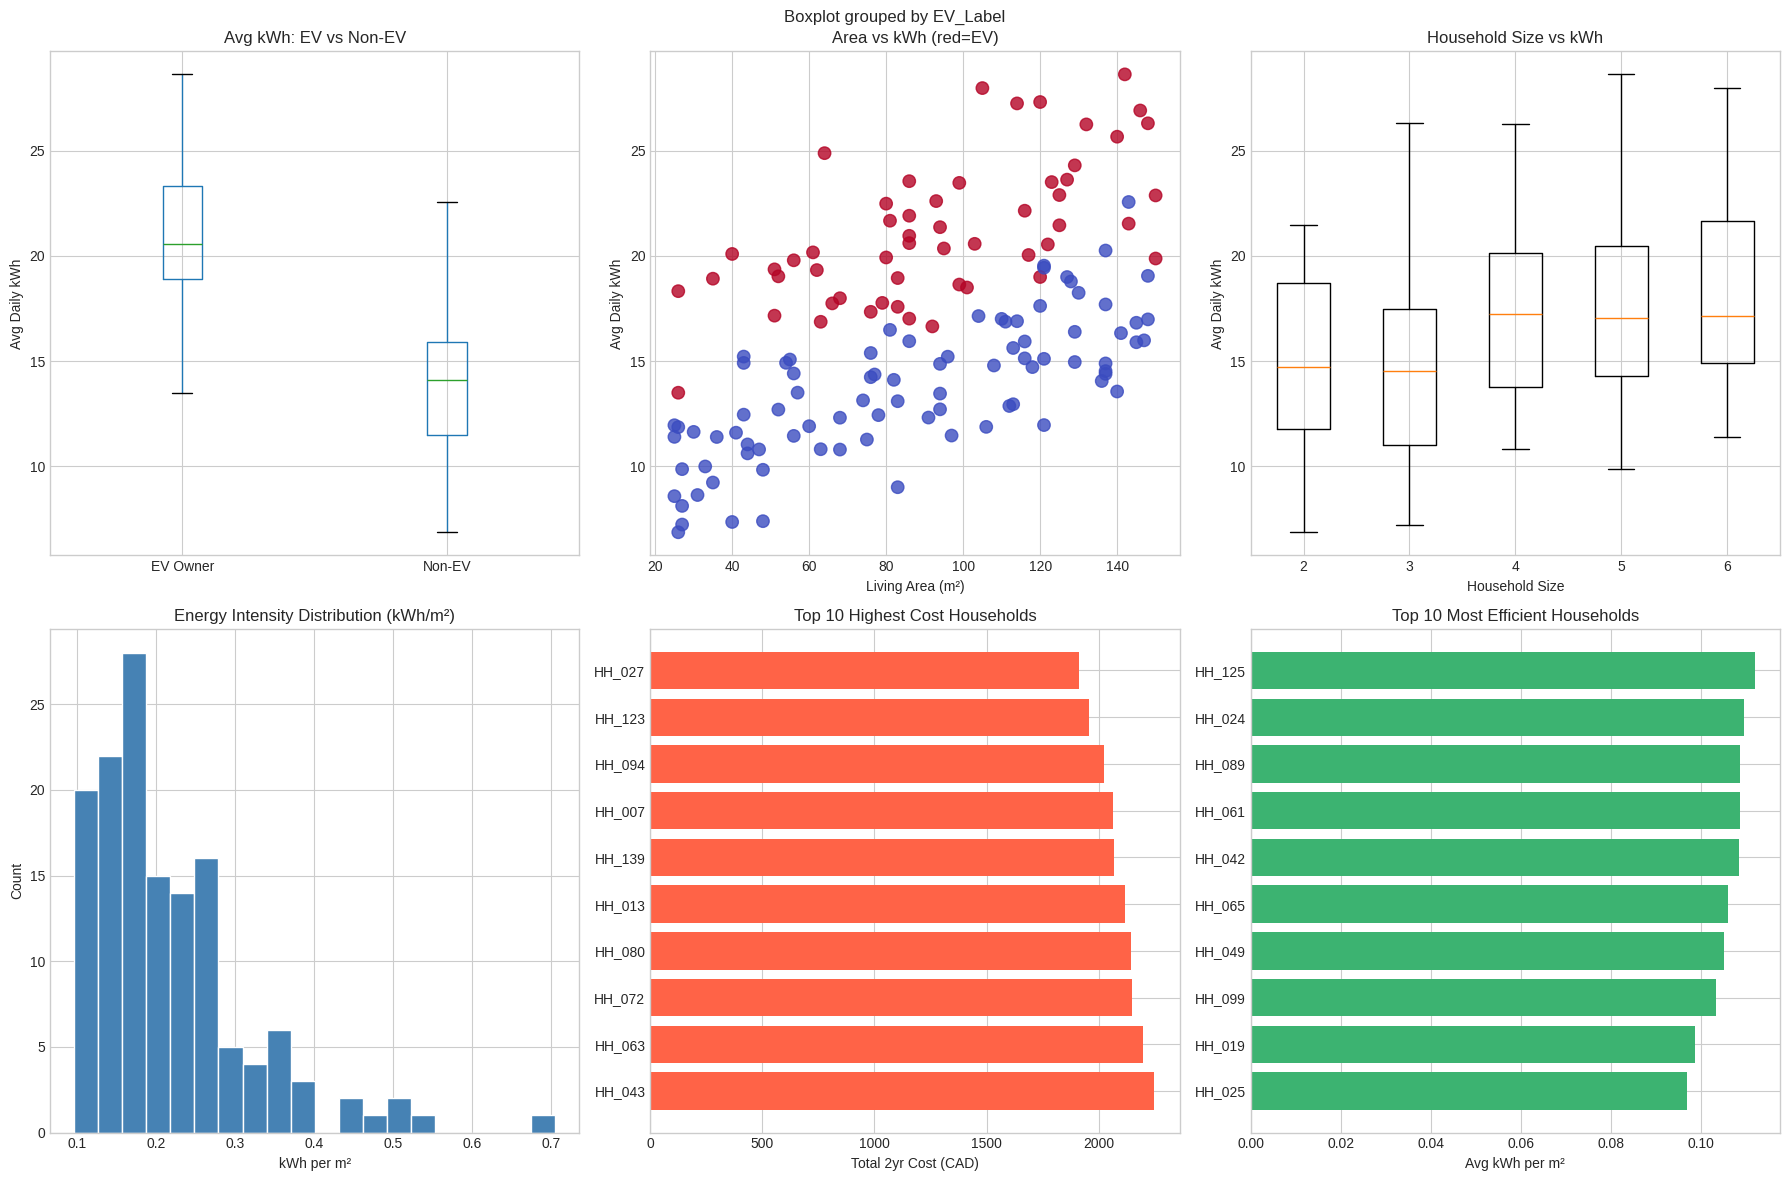

In [6]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 3+11: SEGMENTASI HOUSEHOLD ║
# ╚══════════════════════════════════════╝
hh_profile = df.groupby('Household_ID').agg(
    Avg_kWh=('Daily_kWh','mean'),
    Avg_Cost=('Daily_Cost_CAD','mean'),
    Total_Cost=('Daily_Cost_CAD','sum'),
    kWh_per_m2=('kWh_per_m2','mean'),
    kWh_per_person=('kWh_per_person','mean'),
    HH_Size=('Household_Size','first'),
    Area=('Living_Area_m2','first'),
    Has_EV=('Has_EV_Car','first'),
    Max_AC=('Max_AC_Hours','first')
).reset_index()

hh_profile['EV_Label'] = hh_profile['Has_EV'].map({1:'EV Owner', 0:'Non-EV'})
hh_profile['Size_Cat'] = pd.cut(hh_profile['HH_Size'],
                                  bins=[0,2,4,6], labels=['Small','Medium','Large'])

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Household Segmentation Analysis', fontsize=16, fontweight='bold')

# EV vs Non-EV
hh_profile.boxplot(column='Avg_kWh', by='EV_Label', ax=axes[0,0])
axes[0,0].set_title('Avg kWh: EV vs Non-EV')
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('Avg Daily kWh')

# Area vs kWh
axes[0,1].scatter(hh_profile['Area'], hh_profile['Avg_kWh'],
                  c=hh_profile['Has_EV'], cmap='coolwarm', s=80, alpha=0.8)
axes[0,1].set_xlabel('Living Area (m²)'); axes[0,1].set_ylabel('Avg Daily kWh')
axes[0,1].set_title('Area vs kWh (red=EV)')

# HH Size vs kWh
axes[0,2].boxplot([hh_profile[hh_profile['HH_Size']==s]['Avg_kWh']
                   for s in sorted(hh_profile['HH_Size'].unique())],
                  labels=sorted(hh_profile['HH_Size'].unique()))
axes[0,2].set_xlabel('Household Size'); axes[0,2].set_ylabel('Avg Daily kWh')
axes[0,2].set_title('Household Size vs kWh')

# kWh per m2 distribution
axes[1,0].hist(hh_profile['kWh_per_m2'], bins=20, color='steelblue', edgecolor='white')
axes[1,0].set_xlabel('kWh per m²'); axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Energy Intensity Distribution (kWh/m²)')

# Top 10 costliest households
top10 = hh_profile.nlargest(10, 'Total_Cost')
axes[1,1].barh(top10['Household_ID'], top10['Total_Cost'], color='tomato')
axes[1,1].set_xlabel('Total 2yr Cost (CAD)')
axes[1,1].set_title('Top 10 Highest Cost Households')

# Bottom 10 most efficient
bot10 = hh_profile.nsmallest(10, 'kWh_per_m2')
axes[1,2].barh(bot10['Household_ID'], bot10['kWh_per_m2'], color='mediumseagreen')
axes[1,2].set_xlabel('Avg kWh per m²')
axes[1,2].set_title('Top 10 Most Efficient Households')

plt.tight_layout()
plt.savefig('analysis_03_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

Linear Regression         | R²=0.6495 | RMSE=4.197
Ridge Regression          | R²=0.6495 | RMSE=4.197
Random Forest             | R²=0.6501 | RMSE=4.193
XGBoost                   | R²=0.7091 | RMSE=3.823


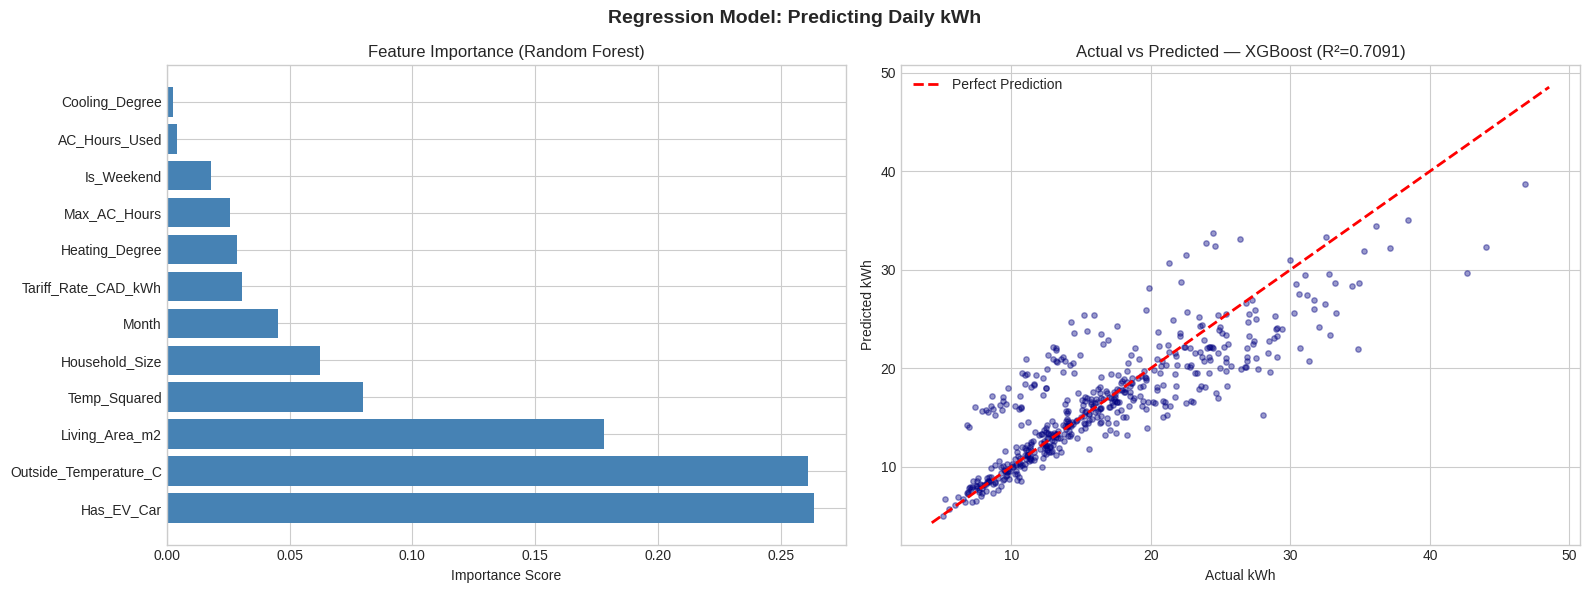


📊 Model Summary:


,R2,RMSE,MAE
Linear Regression,0.6495,4.1968,3.0586
Ridge Regression,0.6495,4.1968,3.0586
Random Forest,0.6501,4.1931,2.7551
XGBoost,0.7091,3.8234,2.5960


In [7]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 4: REGRESSION MODEL        ║
# ╚══════════════════════════════════════╝

# Feature Engineering
features = ['Outside_Temperature_C', 'Temp_Squared', 'Heating_Degree',
            'Cooling_Degree', 'Household_Size', 'Living_Area_m2',
            'Has_EV_Car', 'Max_AC_Hours', 'AC_Hours_Used',
            'Tariff_Rate_CAD_kWh', 'Is_Weekend', 'Month']
target = 'Daily_kWh'

ml_df = df[features + [target, 'Household_ID', 'Date']].dropna()
X = ml_df[features]
y = ml_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred)
    }
    print(f"{name:25s} | R²={results[name]['R2']:.4f} | RMSE={results[name]['RMSE']:.3f}")

# Feature Importance (dari Random Forest)
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Regression Model: Predicting Daily kWh', fontsize=14, fontweight='bold')

# Feature importance
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
axes[0].set_title('Feature Importance (Random Forest)')
axes[0].set_xlabel('Importance Score')

# Actual vs Predicted (best model)
best_model = models['XGBoost']
y_pred_best = best_model.predict(X_test)
axes[1].scatter(y_test[:500], y_pred_best[:500], alpha=0.4, s=15, color='navy')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual kWh'); axes[1].set_ylabel('Predicted kWh')
axes[1].set_title(f'Actual vs Predicted — XGBoost (R²={results["XGBoost"]["R2"]:.4f})')
axes[1].legend()

plt.tight_layout()
plt.savefig('analysis_04_regression.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Model Summary:")
pd.DataFrame(results).T.round(4)

Total outliers (>2.5σ): 265 (0.3%)


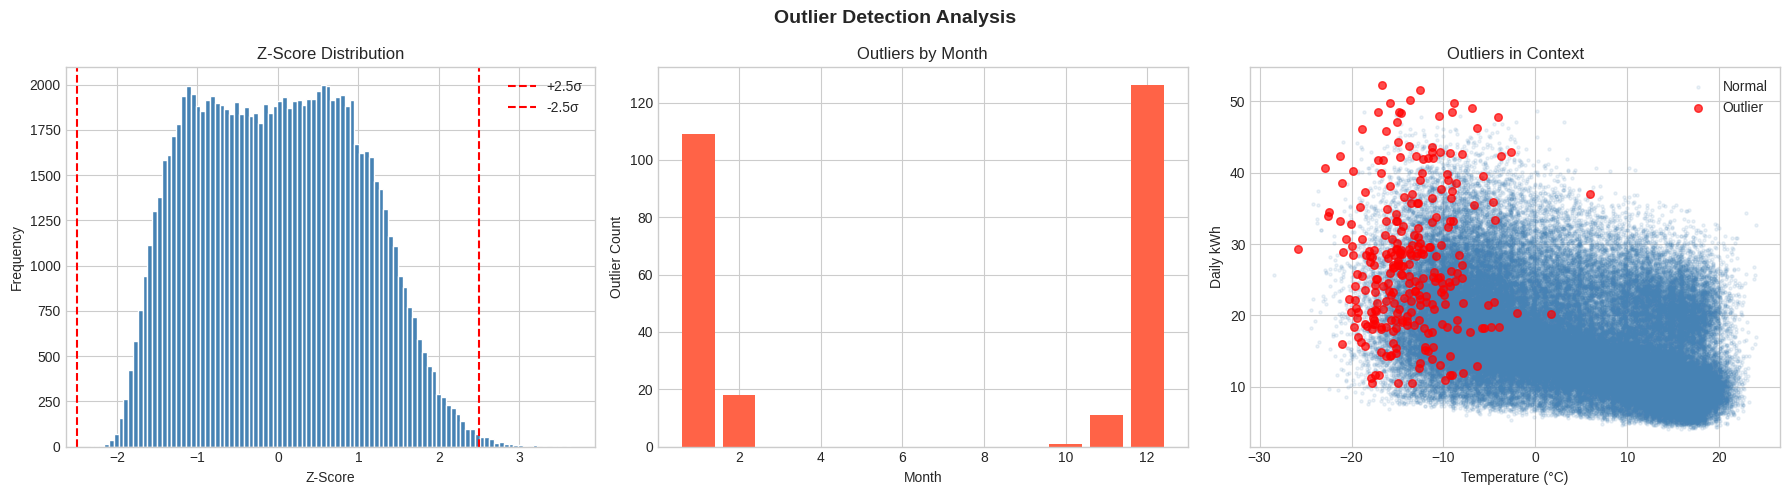

In [8]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 7+12D: OUTLIER DETECTION   ║
# ╚══════════════════════════════════════╝
from scipy import stats

# Z-score per household
df['Z_Score_HH'] = df.groupby('Household_ID')['Daily_kWh'].transform(
    lambda x: stats.zscore(x, ddof=1))
df['Outlier'] = df['Z_Score_HH'].abs() > 2.5
df['Outlier_Cat'] = pd.cut(df['Z_Score_HH'].abs(),
                            bins=[0, 1.5, 2, 2.5, 100],
                            labels=['Normal','Mild','Outlier','Extreme'])

print(f"Total outliers (>2.5σ): {df['Outlier'].sum():,} ({df['Outlier'].mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Outlier Detection Analysis', fontsize=14, fontweight='bold')

# Z-score distribution
axes[0].hist(df['Z_Score_HH'], bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(x=2.5, color='red', ls='--', label='+2.5σ')
axes[0].axvline(x=-2.5, color='red', ls='--', label='-2.5σ')
axes[0].set_xlabel('Z-Score'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Z-Score Distribution')
axes[0].legend()

# Outlier by month
outlier_month = df.groupby('Month')['Outlier'].sum().reset_index()
axes[1].bar(outlier_month['Month'], outlier_month['Outlier'], color='tomato')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Outlier Count')
axes[1].set_title('Outliers by Month')

# Outlier by temperature
axes[2].scatter(df[~df['Outlier']]['Outside_Temperature_C'],
                df[~df['Outlier']]['Daily_kWh'],
                alpha=0.1, s=5, color='steelblue', label='Normal')
axes[2].scatter(df[df['Outlier']]['Outside_Temperature_C'],
                df[df['Outlier']]['Daily_kWh'],
                alpha=0.7, s=30, color='red', label='Outlier')
axes[2].set_xlabel('Temperature (°C)'); axes[2].set_ylabel('Daily kWh')
axes[2].set_title('Outliers in Context')
axes[2].legend()

plt.tight_layout()
plt.savefig('analysis_07_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

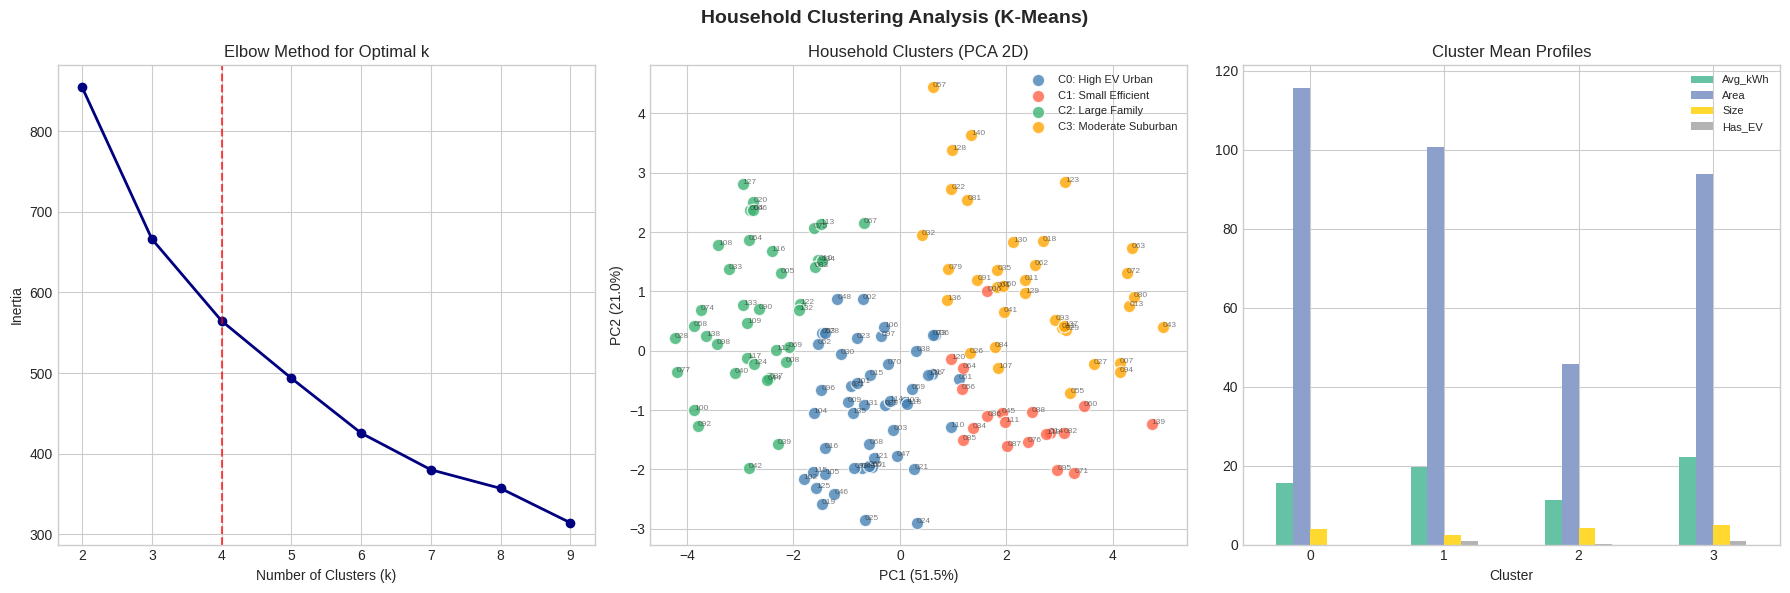


📊 Cluster Summary:
         Avg_kWh  kWh_per_m2     Area   Size  Has_EV
Cluster                                             
0         15.559       0.138  115.625  4.042   0.000
1         19.640       0.207  100.789  2.421   1.000
2         11.181       0.272   45.763  4.263   0.026
3         22.269       0.273   93.857  5.000   0.971


In [9]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 17: CLUSTERING             ║
# ╚══════════════════════════════════════╝
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Household-level features untuk clustering
hh_cluster = df.groupby('Household_ID').agg(
    Avg_kWh=('Daily_kWh','mean'),
    Std_kWh=('Daily_kWh','std'),
    Winter_kWh=('Daily_kWh', lambda x: x[df.loc[x.index,'Season']=='Winter'].mean()),
    Summer_kWh=('Daily_kWh', lambda x: x[df.loc[x.index,'Season']=='Summer'].mean()),
    kWh_per_m2=('kWh_per_m2','mean'),
    kWh_per_person=('kWh_per_person','mean'),
    Area=('Living_Area_m2','first'),
    Size=('Household_Size','first'),
    Has_EV=('Has_EV_Car','first'),
    AC_Usage=('AC_Hours_Used','sum')
).reset_index().dropna()

cluster_features = ['Avg_kWh','Std_kWh','Winter_kWh','Summer_kWh',
                    'kWh_per_m2','kWh_per_person','Area','Size','Has_EV','AC_Usage']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(hh_cluster[cluster_features])

# Elbow method
inertias = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Pilih k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
hh_cluster['Cluster'] = km_final.fit_predict(X_scaled)
cluster_labels = {0:'High EV Urban', 1:'Small Efficient',
                  2:'Large Family', 3:'Moderate Suburban'}

# PCA for visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
hh_cluster['PCA1'] = pca_coords[:,0]
hh_cluster['PCA2'] = pca_coords[:,1]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Household Clustering Analysis (K-Means)', fontsize=14, fontweight='bold')

# Elbow plot
axes[0].plot(list(K_range), inertias, 'o-', color='navy', linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method for Optimal k')
axes[0].axvline(x=4, color='red', ls='--', alpha=0.7)

# PCA scatter
colors = ['steelblue','tomato','mediumseagreen','orange']
for i, (cluster_id, label) in enumerate(cluster_labels.items()):
    mask = hh_cluster['Cluster'] == cluster_id
    axes[1].scatter(hh_cluster[mask]['PCA1'], hh_cluster[mask]['PCA2'],
                   color=colors[i], label=f'C{cluster_id}: {label}',
                   s=80, alpha=0.8, edgecolors='white')
    # Label each point
    for _, row in hh_cluster[mask].iterrows():
        axes[1].annotate(row['Household_ID'].replace('HH_',''),
                        (row['PCA1'], row['PCA2']), fontsize=6, alpha=0.6)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Household Clusters (PCA 2D)')
axes[1].legend(fontsize=8)

# Cluster profile
cluster_profile = hh_cluster.groupby('Cluster')[['Avg_kWh','Area','Size','Has_EV']].mean()
cluster_profile.plot(kind='bar', ax=axes[2], colormap='Set2')
axes[2].set_title('Cluster Mean Profiles')
axes[2].set_xlabel('Cluster'); axes[2].legend(fontsize=8)
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('analysis_17_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Cluster Summary:")
print(hh_cluster.groupby('Cluster')[['Avg_kWh','kWh_per_m2','Area','Size','Has_EV']].mean().round(3))

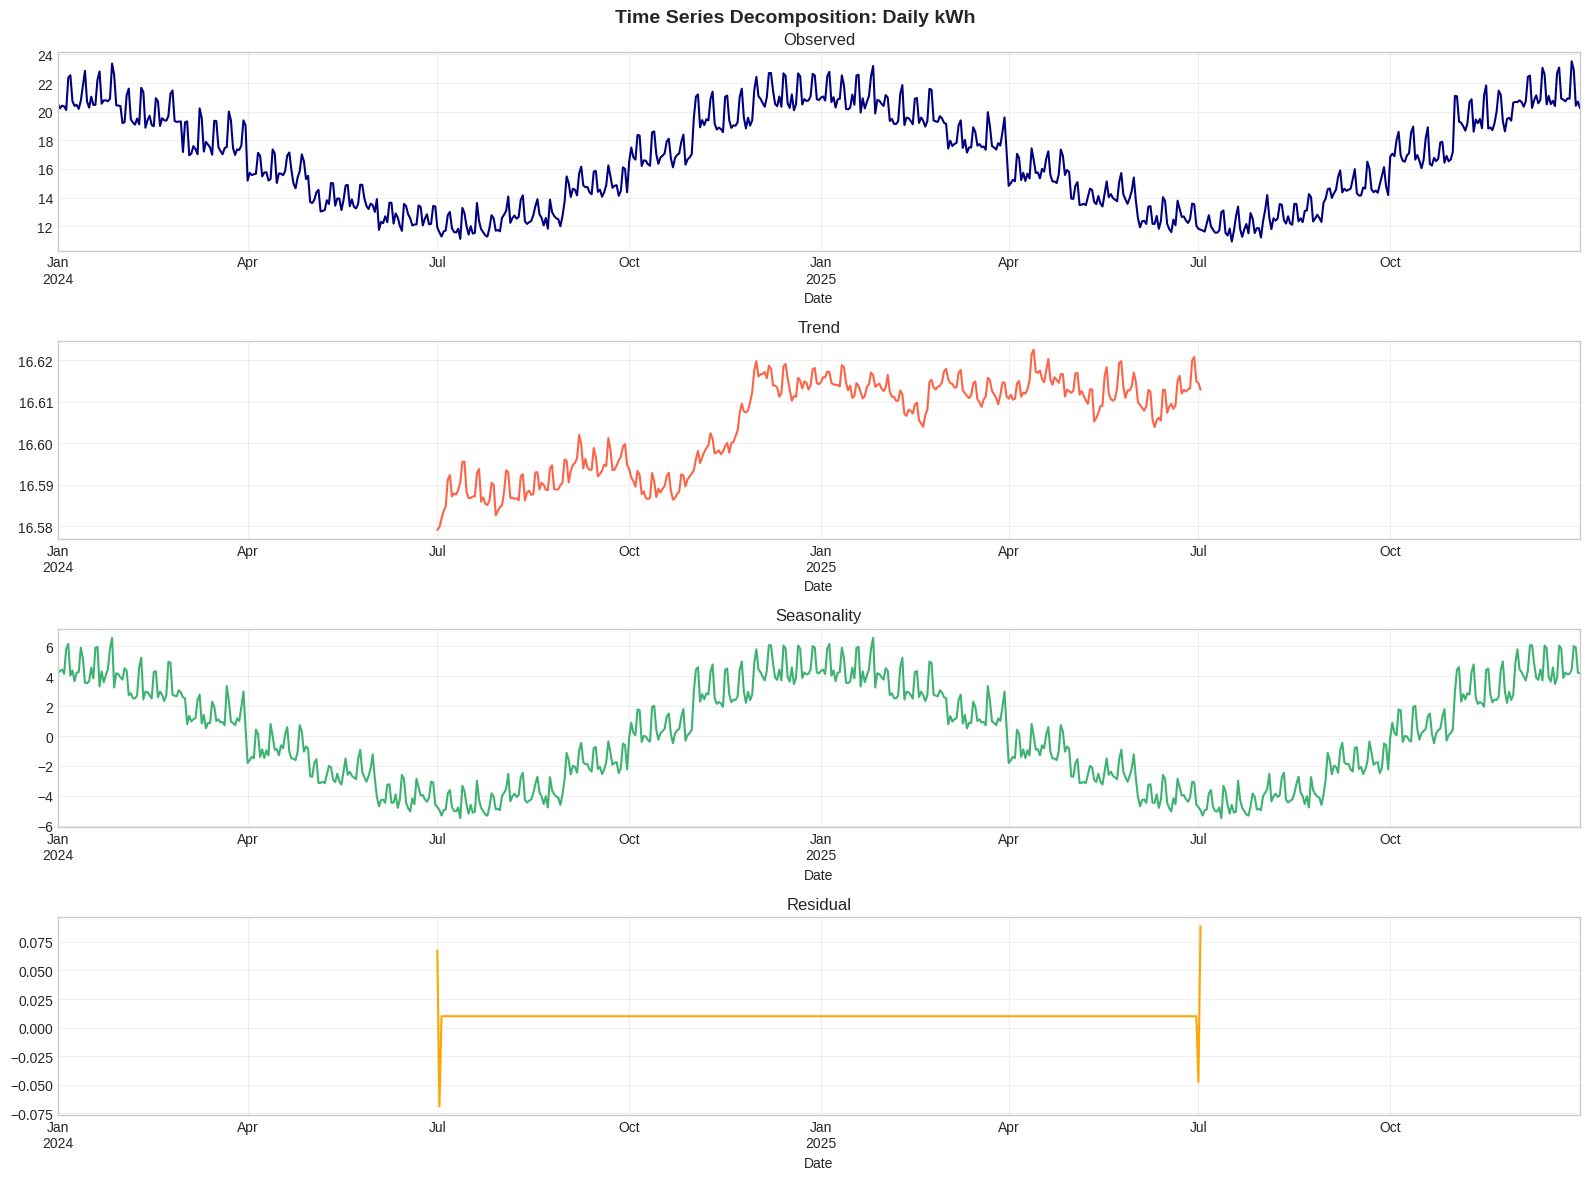

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


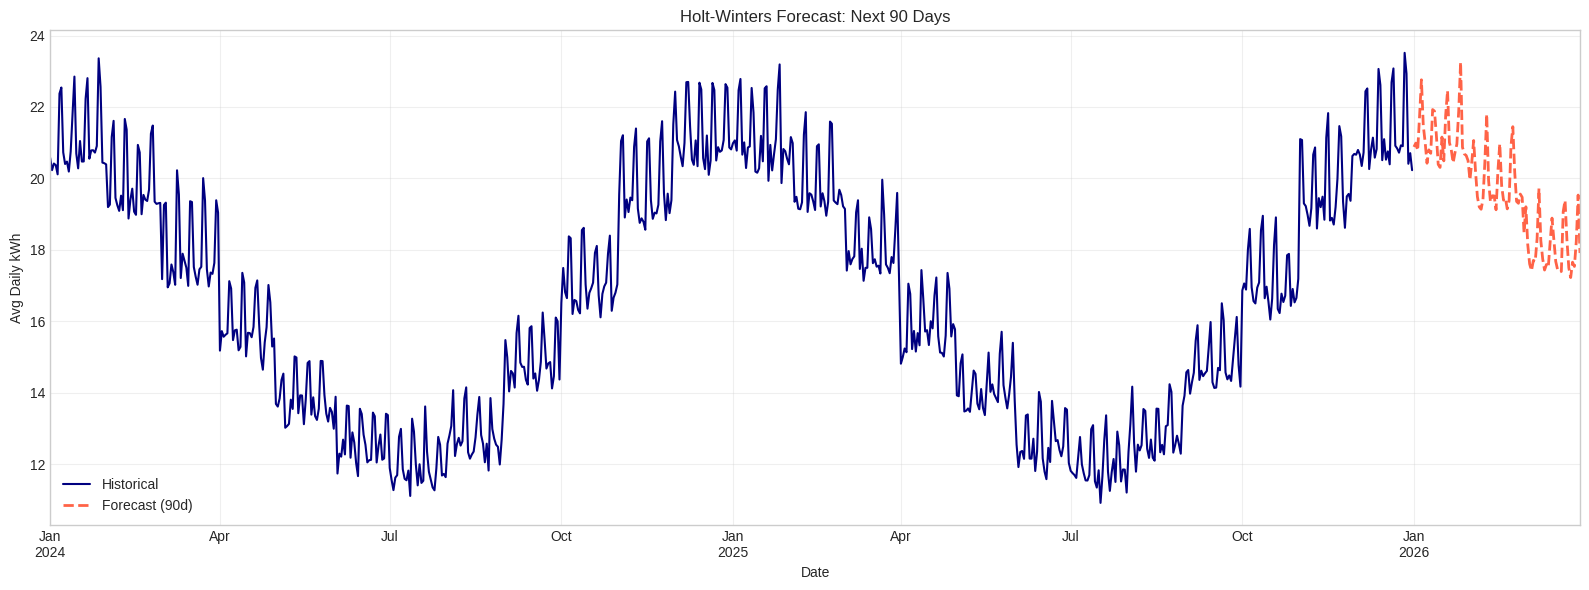

In [10]:
# ╔══════════════════════════════════════╗
# ║  ANALYSIS 13: FORECASTING (Time Series)║
# ╚══════════════════════════════════════╝
# Aggregate daily untuk seluruh dataset
daily_agg = df.groupby('Date').agg(
    Avg_kWh=('Daily_kWh','mean'),
    Avg_Temp=('Outside_Temperature_C','mean')
).reset_index().sort_values('Date')

# Seasonal Decomposition
decomp_series = daily_agg.set_index('Date')['Avg_kWh']
decomposition = seasonal_decompose(decomp_series, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
fig.suptitle('Time Series Decomposition: Daily kWh', fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], title='Observed', color='navy')
decomposition.trend.plot(ax=axes[1], title='Trend', color='tomato')
decomposition.seasonal.plot(ax=axes[2], title='Seasonality', color='mediumseagreen')
decomposition.resid.plot(ax=axes[3], title='Residual', color='orange')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analysis_13_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# Holt-Winters Forecast (next 90 days)
hw_model = ExponentialSmoothing(
    decomp_series,
    trend='add',
    seasonal='add',
    seasonal_periods=365
).fit()

forecast_days = 90
forecast = hw_model.forecast(forecast_days)
forecast_dates = pd.date_range(
    start=daily_agg['Date'].max() + pd.Timedelta(days=1),
    periods=forecast_days
)

fig, ax = plt.subplots(figsize=(16, 6))
daily_agg.set_index('Date')['Avg_kWh'].plot(ax=ax, label='Historical', color='navy', lw=1.5)
pd.Series(forecast.values, index=forecast_dates).plot(
    ax=ax, label='Forecast (90d)', color='tomato', lw=2, ls='--')
ax.set_title('Holt-Winters Forecast: Next 90 Days')
ax.set_xlabel('Date'); ax.set_ylabel('Avg Daily kWh')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('analysis_13_forecast.png', dpi=150, bbox_inches='tight')
plt.show()